# Compare `delta_idm_drmd` in Magnus, Tobias, and Florian wrappers

This notebook compares the perturbation variable `delta_idm_drmd` returned by three CLASS wrappers:

- `classy_NEDE` (Magnus)
- `classy_tobias` (Tobias)
- `classy_Florian` (Florian)

## Goal

The purpose is to test whether the wrappers expose and return the same interacting dark matter perturbation history for the same cosmological model and DRMD settings.

## Strategy

We:

1. define a shared baseline cosmology
2. define one DRMD test case
3. run all three wrappers with identical parameters
4. extract the first scalar perturbation block from `get_perturbations()`
5. read:
   - the x-axis (`tau [Mpc]`)
   - `delta_idm_drmd`
6. interpolate Magnus and Tobias onto Florian's `tau` grid
7. plot:
   - the absolute `delta_idm_drmd`
   - the fractional deviation relative to Florian

## Notes

- This notebook only studies `delta_idm_drmd`.
- We intentionally leave `delta_cdm` for a later cell.
- Since perturbation outputs can have slightly different sampling, interpolation is used before ratios are formed.
- Very early times can contain near-zero values, so ratio plots may need masking to avoid meaningless spikes.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from classy_NEDE import Class as ClassMagnus
from classy_tobias import Class as ClassTobias
from classy_Florian import Class as ClassFlorian


# =============================================================================
# Helpers
# =============================================================================
def run_model(ClassObj, params, label):
    c = ClassObj()
    c.set(params)
    c.compute()
    print(f"[{label}] computed.")
    try:
        d = c.get_current_derived_parameters(["h", "Omega_m", "Omega_r", "z_eq"])
        print(f"[{label}] derived: {d}")
    except Exception:
        try:
            print(f"[{label}] h = {c.h():.6f}")
        except Exception:
            pass
    return c


def cleanup(*cosmos):
    for c in cosmos:
        try:
            c.struct_cleanup()
            c.empty()
        except Exception:
            pass


def get_scalar_block(cosmo, label, block_index=0, verbose=True):
    pert = cosmo.get_perturbations()
    if verbose:
        print(f"\n[{label}] top-level perturbation keys: {list(pert.keys())}")
    if "scalar" not in pert:
        raise KeyError(f"[{label}] No 'scalar' entry in perturbations output.")
    if len(pert["scalar"]) <= block_index:
        raise IndexError(f"[{label}] scalar block index {block_index} not available.")
    block = pert["scalar"][block_index]
    if verbose:
        print(f"[{label}] scalar[{block_index}] keys:")
        for k in block.keys():
            print(f"   {k}")
    return block


def require_key(block, key, label):
    if key not in block:
        raise KeyError(f"[{label}] Missing key '{key}'. Available keys: {list(block.keys())}")
    return np.asarray(block[key])


def sort_unique_xy(x, y):
    x = np.asarray(x)
    y = np.asarray(y)
    order = np.argsort(x)
    x_sorted = x[order]
    y_sorted = y[order]
    x_unique, idx = np.unique(x_sorted, return_index=True)
    y_unique = y_sorted[idx]
    return x_unique, y_unique


def interp_to_reference(x_ref, x_in, y_in):
    x_u, y_u = sort_unique_xy(x_in, y_in)
    return np.interp(x_ref, x_u, y_u)


def safe_fractional_difference(y_num, y_den, eps=1e-30):
    """
    Returns y_num / y_den - 1 with masking near y_den = 0.
    """
    y_num = np.asarray(y_num)
    y_den = np.asarray(y_den)

    out = np.full_like(y_num, np.nan, dtype=float)
    mask = np.isfinite(y_num) & np.isfinite(y_den) & (np.abs(y_den) > eps)
    out[mask] = y_num[mask] / y_den[mask] - 1.0
    return out


def finite_summary(name, fracdiff):
    fd = np.asarray(fracdiff)
    mask = np.isfinite(fd)
    if not np.any(mask):
        print(f"{name}: no finite values")
        return
    print(f"{name}: max |frac diff| = {np.max(np.abs(fd[mask])):.6e}")
    print(f"{name}: min diff [%]   = {100.0*np.min(fd[mask]):.6e}")
    print(f"{name}: max diff [%]   = {100.0*np.max(fd[mask]):.6e}")

In [2]:
# =============================================================================
# Shared cosmology
# =============================================================================
H0        = 67.32
omega_b   = 0.02238
omega_cdm = 0.1201
A_s       = 2.101e-9
n_s       = 0.9660
tau_reio  = 0.0543
k_pivot   = 0.05
T_cmb     = 2.7255
Omega_k   = 0.0
L_MAX     = 2500

DEG      = 1.0
M_NCDM   = 0.06
N_ur_run = max(0.0, 3.046 - DEG)


# =============================================================================
# DRMD settings
# =============================================================================
# OFF case
F_IDM_OFF      = 0.0
DELTA_NEFF_OFF = 0.0
Z_STOP_OFF     = 0.0
G_AH_OFF       = 0.0

# ON case
F_IDM_ON       = 0.03
DELTA_NEFF_ON  = 0.8
Z_STOP_ON      = 5.0e4
G_AH_ON        = 1.0e9


# =============================================================================
# Notebook controls
# =============================================================================
USE_DRMD_ON = True
SCALAR_BLOCK_INDEX = 0
K_OUTPUT_VALUES = "0.02"
X_KEY = "a"
Y_KEY = "delta_idm_drmd"


# =============================================================================
# Parameter builders
# =============================================================================
def base_params():
    return {
        "H0": float(H0),
        "omega_b": float(omega_b),
        "omega_cdm": float(omega_cdm),
        "A_s": float(A_s),
        "n_s": float(n_s),
        "tau_reio": float(tau_reio),
        "k_pivot": float(k_pivot),
        "T_cmb": float(T_cmb),
        "Omega_k": float(Omega_k),

        "output": "tCl,pCl,lCl,mPk",
        "lensing": "yes",
        "l_max_scalars": int(L_MAX),

        "recombination": "recfast",
        "reio_parametrization": "reio_camb",

        "k_output_values": K_OUTPUT_VALUES,

        "input_verbose": 1,
        "background_verbose": 1,
        "perturbations_verbose": 1,
    }


def drmd_off_params():
    p = base_params()
    p.update({
        "N_ur": float(N_ur_run),
        "N_ncdm": 1,
        "m_ncdm": float(M_NCDM),
        "deg_ncdm": float(DEG),
        "T_ncdm": 0.71611,

        "f_idm_drmd": float(F_IDM_OFF),
        "delta_Neff_drmd": float(DELTA_NEFF_OFF),
        "z_stop": float(Z_STOP_OFF),
        "G_over_aH_drmd_ini": float(G_AH_OFF),
    })
    return p


def drmd_on_params():
    p = base_params()
    p.update({
        "N_ur": float(N_ur_run),
        "N_ncdm": 1,
        "m_ncdm": float(M_NCDM),
        "deg_ncdm": float(DEG),
        "T_ncdm": 0.71611,

        "f_idm_drmd": float(F_IDM_ON),
        "delta_Neff_drmd": float(DELTA_NEFF_ON),
        "z_stop": float(Z_STOP_ON),
        "G_over_aH_drmd_ini": float(G_AH_ON),
    })
    return p


params = drmd_on_params() if USE_DRMD_ON else drmd_off_params()
case_label = "DRMD ON" if USE_DRMD_ON else "DRMD OFF"

print("========================================")
print("delta_idm_drmd wrapper comparison")
print("Magnus vs Tobias vs Florian")
print("========================================")
print(f"\nCase: {case_label}\n")

for k, v in params.items():
    print(f"{k}: {v}")

delta_idm_drmd wrapper comparison
Magnus vs Tobias vs Florian

Case: DRMD ON

H0: 67.32
omega_b: 0.02238
omega_cdm: 0.1201
A_s: 2.101e-09
n_s: 0.966
tau_reio: 0.0543
k_pivot: 0.05
T_cmb: 2.7255
Omega_k: 0.0
output: tCl,pCl,lCl,mPk
lensing: yes
l_max_scalars: 2500
recombination: recfast
reio_parametrization: reio_camb
k_output_values: 0.02
input_verbose: 1
background_verbose: 1
perturbations_verbose: 1
N_ur: 2.046
N_ncdm: 1
m_ncdm: 0.06
deg_ncdm: 1.0
T_ncdm: 0.71611
f_idm_drmd: 0.03
delta_Neff_drmd: 0.8
z_stop: 50000.0
G_over_aH_drmd_ini: 1000000000.0


Reading input parameters
[Magnus] computed.
[Magnus] h = 0.673200
[Tobias] computed.
[Tobias] h = 0.673200
[Florian] computed.
[Florian] h = 0.673200

[Magnus] top-level perturbation keys: ['scalar']
[Magnus] scalar[0] keys:
   tau [Mpc]
   a
   delta_g
   theta_g
   shear_g
   pol0_g
   pol1_g
   pol2_g
   delta_b
   theta_b
   psi
   phi
   delta_ur
   theta_ur
   shear_ur
   delta_idr_drmd
   theta_idr_drmd
   delta_cdm
   theta_cdm
   delta_idm_drmd
   theta_idm_drmd
   delta_ncdm[0]
   theta_ncdm[0]
   shear_ncdm[0]
   cs2_ncdm[0]

[Tobias] top-level perturbation keys: ['scalar']
[Tobias] scalar[0] keys:
   tau [Mpc]
   a
   delta_g
   theta_g
   shear_g
   pol0_g
   pol1_g
   pol2_g
   delta_b
   theta_b
   psi
   phi
   delta_ur
   theta_ur
   shear_ur
   delta_idr_drmd
   theta_idr_drmd
   delta_idm_drmd
   theta_idm_drmd
   delta_cdm
   theta_cdm
   delta_ncdm[0]
   theta_ncdm[0]
   shear_ncdm[0]
   cs2_ncdm[0]

[Florian] top-level perturbation keys: ['scalar']
[Florian] scala

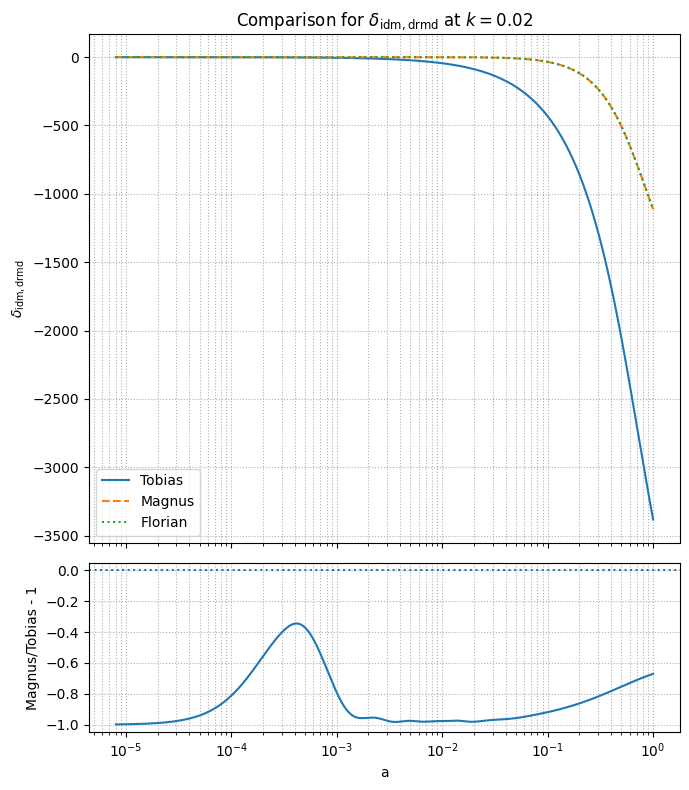

max |Magnus/Tobias - 1| = 9.982e-01
min (Magnus/Tobias - 1) = -9.982e-01
max (Magnus/Tobias - 1) = -3.448e-01


In [3]:
# =============================================================================
# Run all three models
# =============================================================================
cM = run_model(ClassMagnus,  params, "Magnus")
cT = run_model(ClassTobias,  params, "Tobias")
cF = run_model(ClassFlorian, params, "Florian")


# =============================================================================
# Read scalar perturbation block
# =============================================================================
bM = get_scalar_block(cM, "Magnus",  block_index=SCALAR_BLOCK_INDEX, verbose=True)
bT = get_scalar_block(cT, "Tobias",  block_index=SCALAR_BLOCK_INDEX, verbose=True)
bF = get_scalar_block(cF, "Florian", block_index=SCALAR_BLOCK_INDEX, verbose=True)

aM = require_key(bM, "a", "Magnus")
aT = require_key(bT, "a", "Tobias")
aF = require_key(bF, "a", "Florian")

d_idm_M = require_key(bM, "delta_idm_drmd", "Magnus")
d_idm_T = require_key(bT, "delta_idm_drmd", "Tobias")
d_idm_F = require_key(bF, "delta_idm_drmd", "Florian")


# =============================================================================
# Interpolate onto common a-grid (use Florian grid as reference)
# =============================================================================
a_ref = np.asarray(aF)

d_idm_M_ref = interp_to_reference(a_ref, aM, d_idm_M)
d_idm_T_ref = interp_to_reference(a_ref, aT, d_idm_T)
d_idm_F_ref = np.asarray(d_idm_F)


# =============================================================================
# Plot: delta_idm_drmd + Magnus/Tobias - 1
# =============================================================================
dev = d_idm_M_ref / d_idm_T_ref - 1.0

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(7, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]}
)

ax1.plot(a_ref, d_idm_T_ref, label="Tobias")
ax1.plot(a_ref, d_idm_M_ref, ls="--", label="Magnus")
ax1.plot(a_ref, d_idm_F_ref, ls=":", label="Florian")
ax1.set_xscale("log")
ax1.set_ylabel(r"$\delta_{\rm idm,drmd}$")
ax1.set_title(r"Comparison for $\delta_{\rm idm,drmd}$ at $k=0.02$")
ax1.legend()
ax1.grid(True, which="both", ls=":")

ax2.semilogx(a_ref, dev)
ax2.axhline(0.0, ls=":")
ax2.set_xlabel("a")
ax2.set_ylabel("Magnus/Tobias - 1")
ax2.grid(True, which="both", ls=":")

plt.tight_layout()
plt.show()

finite = np.isfinite(dev)
if np.any(finite):
    print(f"max |Magnus/Tobias - 1| = {np.max(np.abs(dev[finite])):.3e}")
    print(f"min (Magnus/Tobias - 1) = {np.min(dev[finite]):.3e}")
    print(f"max (Magnus/Tobias - 1) = {np.max(dev[finite]):.3e}")
else:
    print("No finite ratio values.")

# Optional cleanup
# cleanup(cM, cT, cF)

Reading input parameters
[Magnus] computed.
[Magnus] h = 0.673200
[Tobias] computed.
[Tobias] h = 0.673200
DEBUG split(prepass): legacy_flag=1 legacy_N=1  flag_std=0 flag_int=0  Nstd_in=0 Nint_in=0  => Nstd=1 Nint=0 Ntot=1 (local N_ncdm=1)
DEBUG split(Geff_final): Nstd=1 Nint=0 Ntot=1  Geff_species=0.000e+00
 -> matched budget equations by adjusting Omega_Lambda = 0.684101
Running CLASS version v3.2.5
Computing background
 -> non-cold dark matter species with i=1 has m_i = 6.000000e-02 eV (so m_i / omega_i =9.313858e+01 eV)
 -> ncdm species i=1 sampled with 11 (resp. 5) points for purpose of background (resp. perturbation) integration. In the relativistic limit it gives Delta N_eff = 1.0132
 -> dark radiation Delta N_eff (DRMD) 8.000000e-01
 -> age = 13.797149 Gyr
 -> conformal age = 14136.427010 Mpc
 -> N_eff = 3.8592 (summed over all species that are non-relativistic at early times) 
 -> radiation/matter equality at z = 3070.496810
    corresponding to conformal time = 118.703603 Mpc

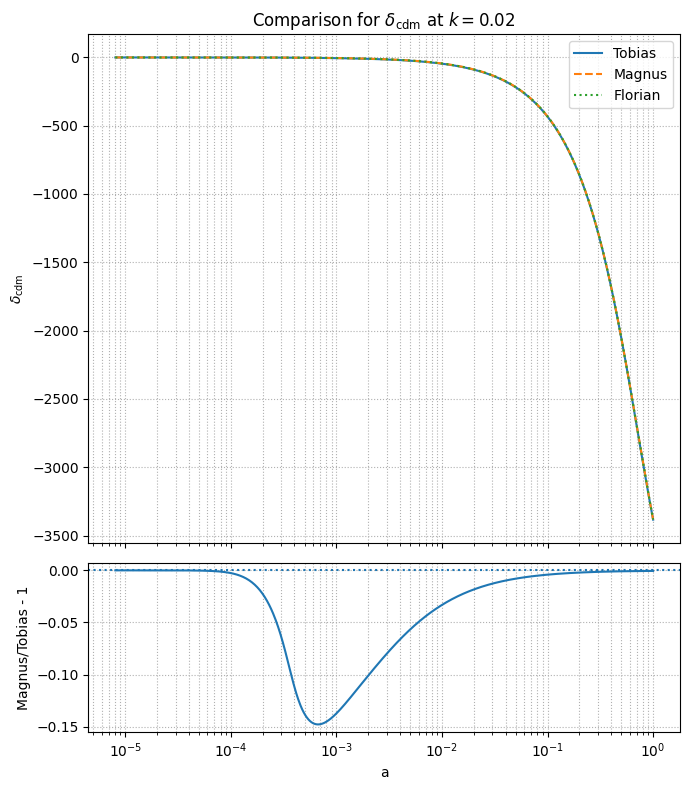

max |Magnus/Tobias - 1| = 1.479e-01
min (Magnus/Tobias - 1) = -1.479e-01
max (Magnus/Tobias - 1) = 6.540e-07


In [4]:
# =============================================================================
# Run all three models
# =============================================================================
cM = run_model(ClassMagnus,  params, "Magnus")
cT = run_model(ClassTobias,  params, "Tobias")
cF = run_model(ClassFlorian, params, "Florian")


# =============================================================================
# Read scalar perturbation block
# =============================================================================
bM = get_scalar_block(cM, "Magnus",  block_index=SCALAR_BLOCK_INDEX, verbose=True)
bT = get_scalar_block(cT, "Tobias",  block_index=SCALAR_BLOCK_INDEX, verbose=True)
bF = get_scalar_block(cF, "Florian", block_index=SCALAR_BLOCK_INDEX, verbose=True)

aM = require_key(bM, "a", "Magnus")
aT = require_key(bT, "a", "Tobias")
aF = require_key(bF, "a", "Florian")

d_cdm_M = require_key(bM, "delta_cdm", "Magnus")
d_cdm_T = require_key(bT, "delta_cdm", "Tobias")
d_cdm_F = require_key(bF, "delta_cdm", "Florian")


# =============================================================================
# Interpolate onto common a-grid (use Florian grid as reference)
# =============================================================================
a_ref = np.asarray(aF)

d_cdm_M_ref = interp_to_reference(a_ref, aM, d_cdm_M)
d_cdm_T_ref = interp_to_reference(a_ref, aT, d_cdm_T)
d_cdm_F_ref = np.asarray(d_cdm_F)


# =============================================================================
# Plot: delta_cdm + Magnus/Tobias - 1
# =============================================================================
dev = d_cdm_M_ref / d_cdm_T_ref - 1.0

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(7, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]}
)

ax1.plot(a_ref, d_cdm_T_ref, label="Tobias")
ax1.plot(a_ref, d_cdm_M_ref, ls="--", label="Magnus")
ax1.plot(a_ref, d_cdm_F_ref, ls=":", label="Florian")
ax1.set_xscale("log")
ax1.set_ylabel(r"$\delta_{\rm cdm}$")
ax1.set_title(r"Comparison for $\delta_{\rm cdm}$ at $k=0.02$")
ax1.legend()
ax1.grid(True, which="both", ls=":")

ax2.semilogx(a_ref, dev)
ax2.axhline(0.0, ls=":")
ax2.set_xlabel("a")
ax2.set_ylabel("Magnus/Tobias - 1")
ax2.grid(True, which="both", ls=":")

plt.tight_layout()
plt.show()

finite = np.isfinite(dev)
if np.any(finite):
    print(f"max |Magnus/Tobias - 1| = {np.max(np.abs(dev[finite])):.3e}")
    print(f"min (Magnus/Tobias - 1) = {np.min(dev[finite]):.3e}")
    print(f"max (Magnus/Tobias - 1) = {np.max(dev[finite]):.3e}")
else:
    print("No finite ratio values.")

# Optional cleanup
# cleanup(cM, cT, cF)

### Huge deviation for delta_idm. Localize the problem

Reading input parameters
[Magnus] computed.
[Magnus] h = 0.673200
[Tobias] computed.
[Tobias] h = 0.673200
[Florian] computed.
[Florian] h = 0.673200

[Magnus] top-level perturbation keys: ['scalar']
[Magnus] scalar[0] keys:
   tau [Mpc]
   a
   delta_g
   theta_g
   shear_g
   pol0_g
   pol1_g
   pol2_g
   delta_b
   theta_b
   psi
   phi
   delta_ur
   theta_ur
   shear_ur
   delta_idr_drmd
   theta_idr_drmd
   delta_cdm
   theta_cdm
   delta_idm_drmd
   theta_idm_drmd
   delta_ncdm[0]
   theta_ncdm[0]
   shear_ncdm[0]
   cs2_ncdm[0]

[Tobias] top-level perturbation keys: ['scalar']
[Tobias] scalar[0] keys:
   tau [Mpc]
   a
   delta_g
   theta_g
   shear_g
   pol0_g
   pol1_g
   pol2_g
   delta_b
   theta_b
   psi
   phi
   delta_ur
   theta_ur
   shear_ur
   delta_idr_drmd
   theta_idr_drmd
   delta_idm_drmd
   theta_idm_drmd
   delta_cdm
   theta_cdm
   delta_ncdm[0]
   theta_ncdm[0]
   shear_ncdm[0]
   cs2_ncdm[0]

[Florian] top-level perturbation keys: ['scalar']
[Florian] scala

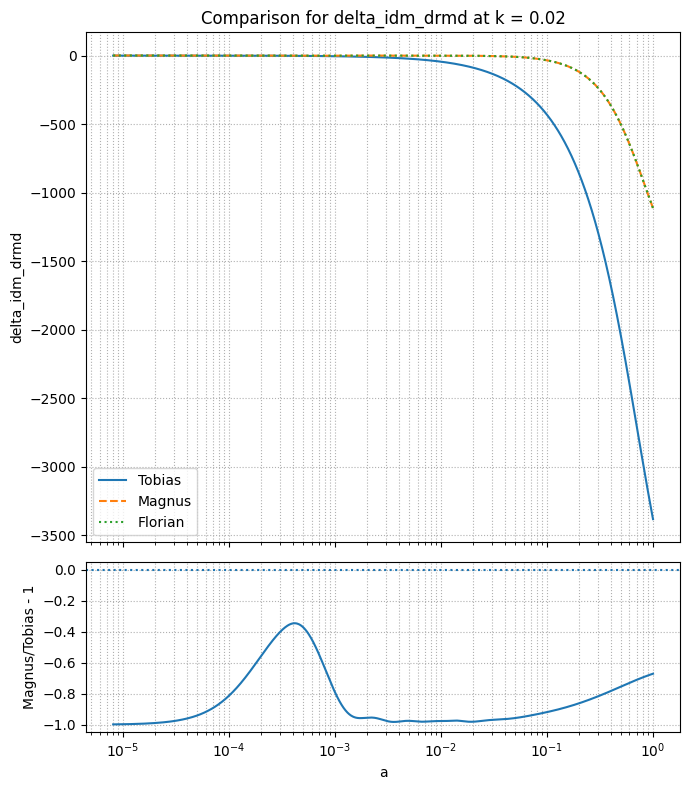


Summary for delta_idm_drmd:
  Magnus/Tobias - 1: max |ratio-1| = 9.982e-01
  Magnus/Tobias - 1: min (ratio-1) = -9.982e-01
  Magnus/Tobias - 1: max (ratio-1) = -3.448e-01
  Magnus/Florian - 1: max |ratio-1| = 0.000e+00
  Magnus/Florian - 1: min (ratio-1) = 0.000e+00
  Magnus/Florian - 1: max (ratio-1) = 0.000e+00
  Tobias/Florian - 1: max |ratio-1| = 5.554e+02
  Tobias/Florian - 1: min (ratio-1) = 5.262e-01
  Tobias/Florian - 1: max (ratio-1) = 5.554e+02

Checking variable: theta_idm_drmd


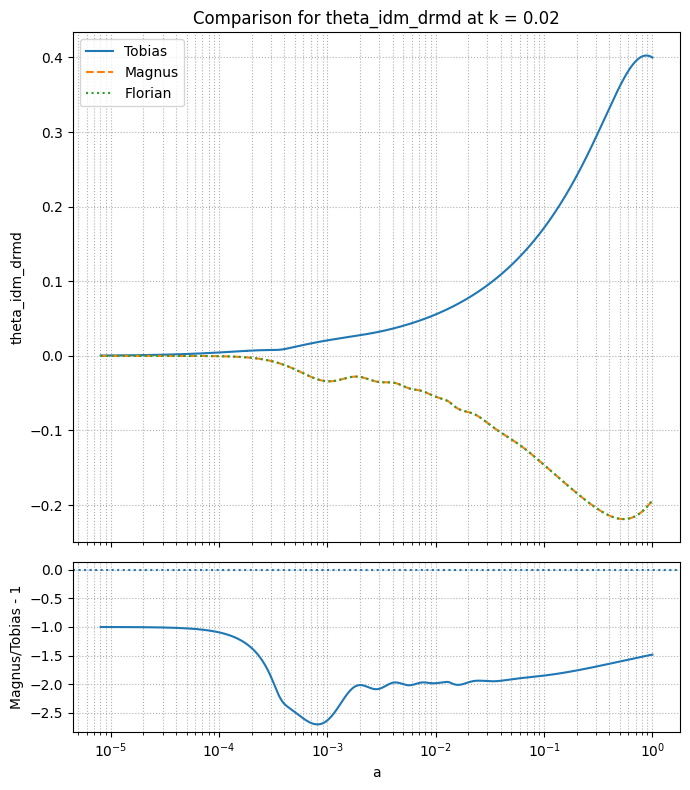


Summary for theta_idm_drmd:
  Magnus/Tobias - 1: max |ratio-1| = 2.707e+00
  Magnus/Tobias - 1: min (ratio-1) = -2.707e+00
  Magnus/Tobias - 1: max (ratio-1) = -1.001e+00
  Magnus/Florian - 1: max |ratio-1| = 0.000e+00
  Magnus/Florian - 1: min (ratio-1) = 0.000e+00
  Magnus/Florian - 1: max (ratio-1) = 0.000e+00
  Tobias/Florian - 1: max |ratio-1| = 1.496e+03
  Tobias/Florian - 1: min (ratio-1) = -1.496e+03
  Tobias/Florian - 1: max (ratio-1) = -1.586e+00

Checking variable: delta_idr_drmd


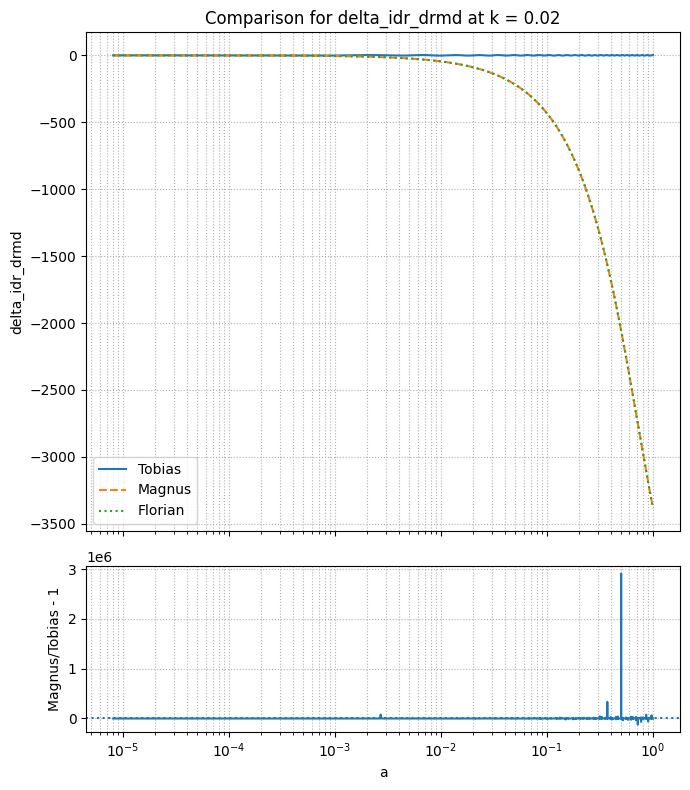


Summary for delta_idr_drmd:
  Magnus/Tobias - 1: max |ratio-1| = 2.910e+06
  Magnus/Tobias - 1: min (ratio-1) = -1.218e+05
  Magnus/Tobias - 1: max (ratio-1) = 2.910e+06
  Magnus/Florian - 1: max |ratio-1| = 0.000e+00
  Magnus/Florian - 1: min (ratio-1) = 0.000e+00
  Magnus/Florian - 1: max (ratio-1) = 0.000e+00
  Tobias/Florian - 1: max |ratio-1| = 1.097e+00
  Tobias/Florian - 1: min (ratio-1) = -1.097e+00
  Tobias/Florian - 1: max (ratio-1) = 3.333e-01

Checking variable: theta_idr_drmd


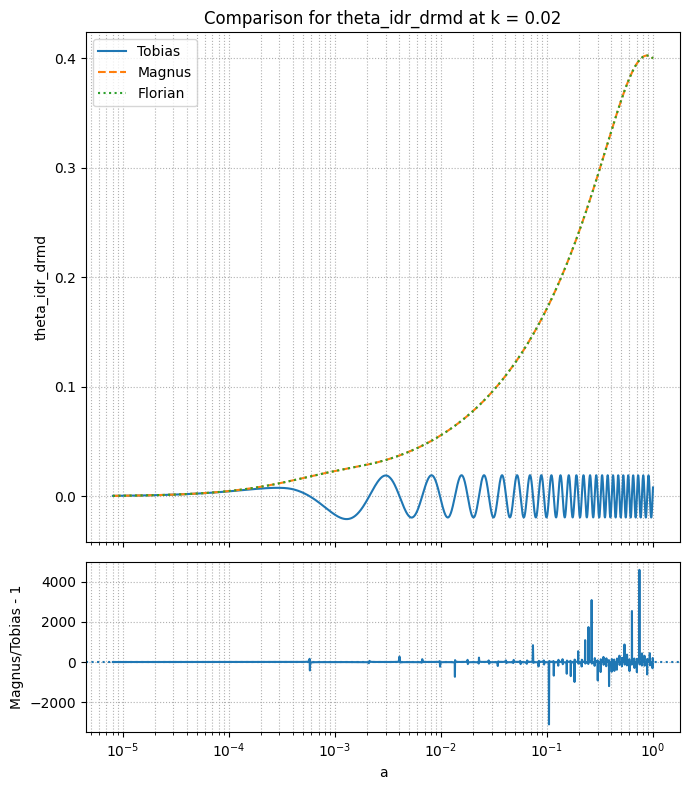


Summary for theta_idr_drmd:
  Magnus/Tobias - 1: max |ratio-1| = 4.604e+03
  Magnus/Tobias - 1: min (ratio-1) = -3.117e+03
  Magnus/Tobias - 1: max (ratio-1) = 4.604e+03
  Magnus/Florian - 1: max |ratio-1| = 0.000e+00
  Magnus/Florian - 1: min (ratio-1) = 0.000e+00
  Magnus/Florian - 1: max (ratio-1) = 0.000e+00
  Tobias/Florian - 1: max |ratio-1| = 1.831e+00
  Tobias/Florian - 1: min (ratio-1) = -1.831e+00
  Tobias/Florian - 1: max (ratio-1) = -4.509e-04

Checking variable: psi


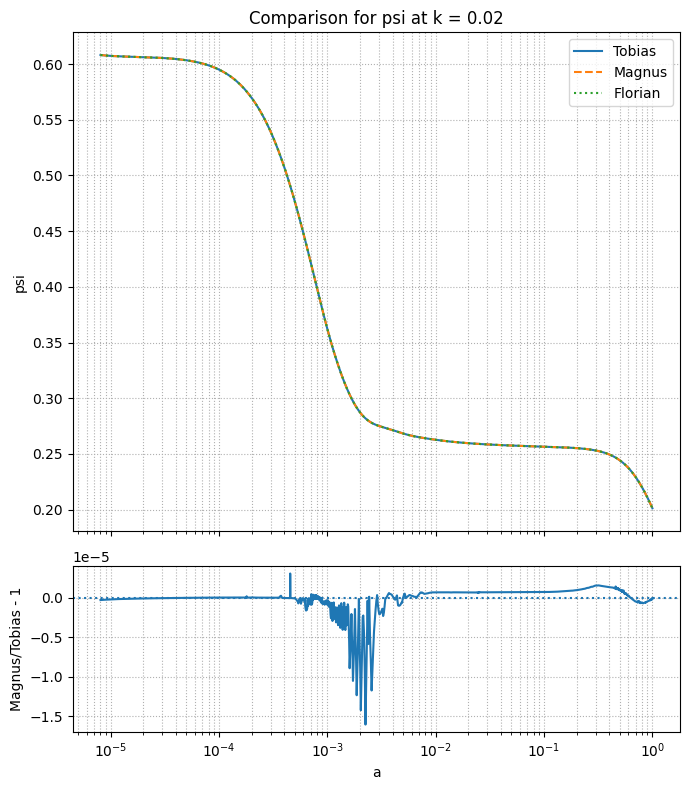


Summary for psi:
  Magnus/Tobias - 1: max |ratio-1| = 1.606e-05
  Magnus/Tobias - 1: min (ratio-1) = -1.606e-05
  Magnus/Tobias - 1: max (ratio-1) = 3.071e-06
  Magnus/Florian - 1: max |ratio-1| = 0.000e+00
  Magnus/Florian - 1: min (ratio-1) = 0.000e+00
  Magnus/Florian - 1: max (ratio-1) = 0.000e+00
  Tobias/Florian - 1: max |ratio-1| = 1.606e-05
  Tobias/Florian - 1: min (ratio-1) = -3.071e-06
  Tobias/Florian - 1: max (ratio-1) = 1.606e-05

Checking variable: phi


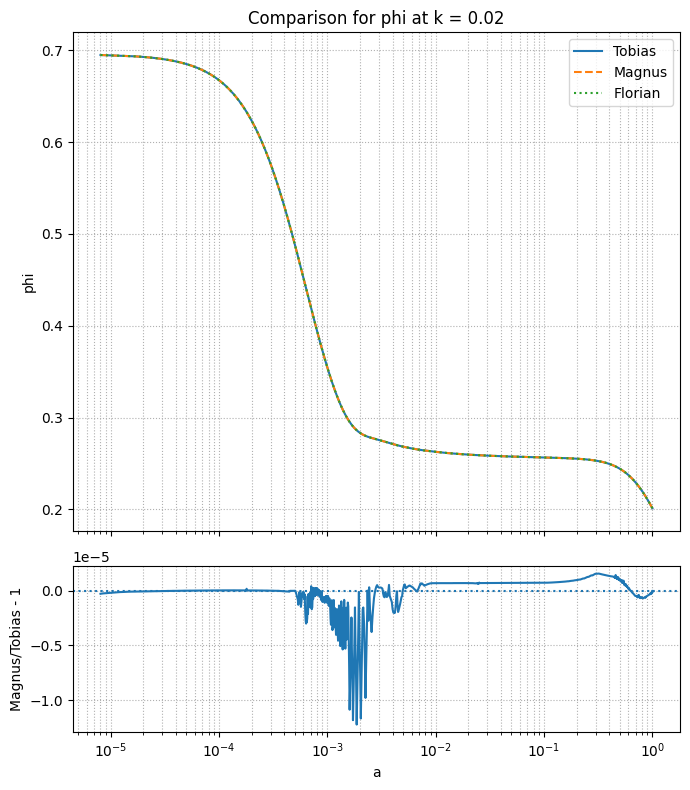


Summary for phi:
  Magnus/Tobias - 1: max |ratio-1| = 1.223e-05
  Magnus/Tobias - 1: min (ratio-1) = -1.223e-05
  Magnus/Tobias - 1: max (ratio-1) = 1.567e-06
  Magnus/Florian - 1: max |ratio-1| = 0.000e+00
  Magnus/Florian - 1: min (ratio-1) = 0.000e+00
  Magnus/Florian - 1: max (ratio-1) = 0.000e+00
  Tobias/Florian - 1: max |ratio-1| = 1.223e-05
  Tobias/Florian - 1: min (ratio-1) = -1.567e-06
  Tobias/Florian - 1: max (ratio-1) = 1.223e-05

Checking variable: delta_cdm


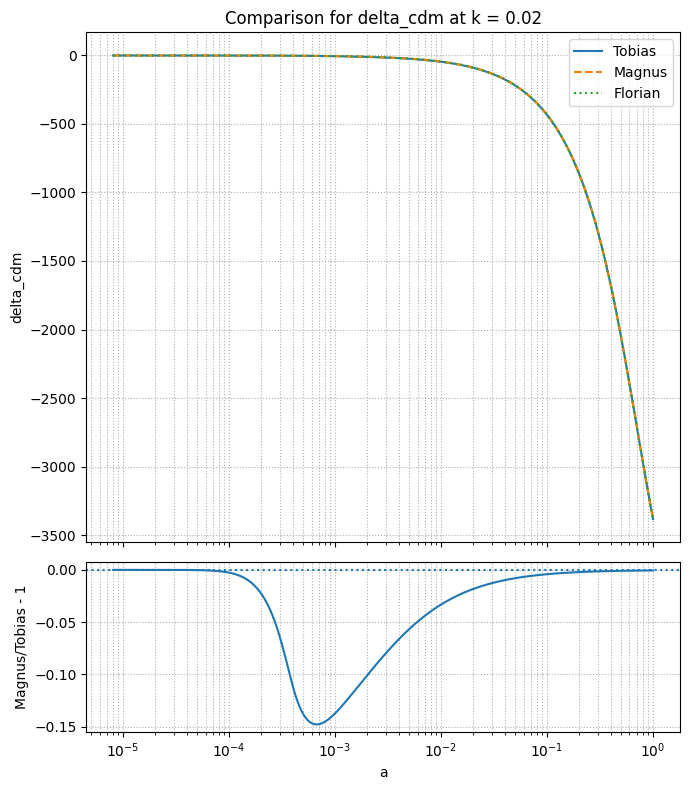


Summary for delta_cdm:
  Magnus/Tobias - 1: max |ratio-1| = 1.479e-01
  Magnus/Tobias - 1: min (ratio-1) = -1.479e-01
  Magnus/Tobias - 1: max (ratio-1) = 6.540e-07
  Magnus/Florian - 1: max |ratio-1| = 0.000e+00
  Magnus/Florian - 1: min (ratio-1) = 0.000e+00
  Magnus/Florian - 1: max (ratio-1) = 0.000e+00
  Tobias/Florian - 1: max |ratio-1| = 1.736e-01
  Tobias/Florian - 1: min (ratio-1) = -6.540e-07
  Tobias/Florian - 1: max (ratio-1) = 1.736e-01

Checking variable: theta_cdm


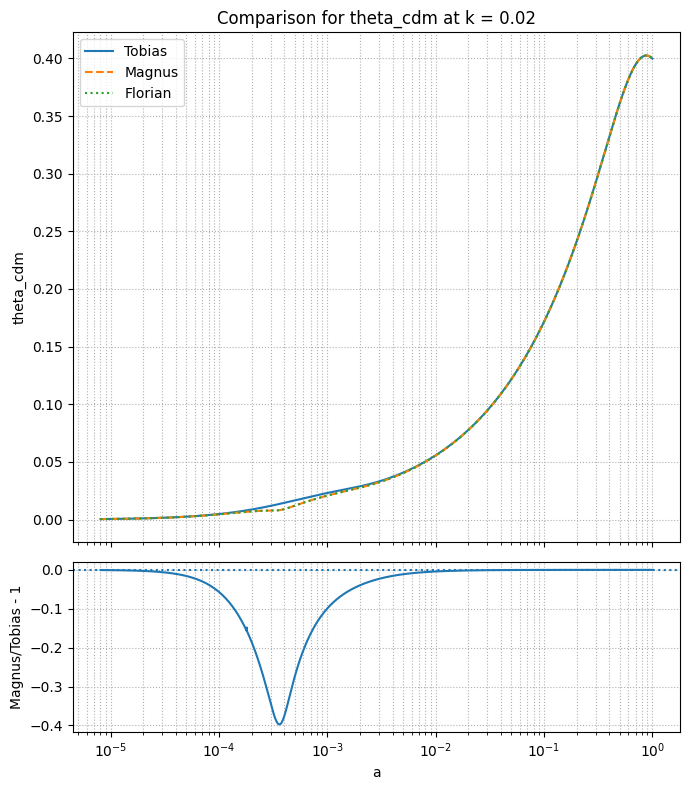


Summary for theta_cdm:
  Magnus/Tobias - 1: max |ratio-1| = 3.974e-01
  Magnus/Tobias - 1: min (ratio-1) = -3.974e-01
  Magnus/Tobias - 1: max (ratio-1) = -3.210e-06
  Magnus/Florian - 1: max |ratio-1| = 0.000e+00
  Magnus/Florian - 1: min (ratio-1) = 0.000e+00
  Magnus/Florian - 1: max (ratio-1) = 0.000e+00
  Tobias/Florian - 1: max |ratio-1| = 6.596e-01
  Tobias/Florian - 1: min (ratio-1) = 3.210e-06
  Tobias/Florian - 1: max (ratio-1) = 6.596e-01


In [5]:
# =============================================================================
# Step 1 diagnostic:
# Compare a set of perturbation variables to see whether only delta_idm_drmd
# is wrong, or whether the whole interacting sector / metric sector differs.
# =============================================================================

# -----------------------------------------------------------------------------
# Run all three models
# -----------------------------------------------------------------------------
cM = run_model(ClassMagnus,  params, "Magnus")
cT = run_model(ClassTobias,  params, "Tobias")
cF = run_model(ClassFlorian, params, "Florian")


# -----------------------------------------------------------------------------
# Read scalar perturbation block
# -----------------------------------------------------------------------------
bM = get_scalar_block(cM, "Magnus",  block_index=SCALAR_BLOCK_INDEX, verbose=True)
bT = get_scalar_block(cT, "Tobias",  block_index=SCALAR_BLOCK_INDEX, verbose=True)
bF = get_scalar_block(cF, "Florian", block_index=SCALAR_BLOCK_INDEX, verbose=True)

aM = require_key(bM, "a", "Magnus")
aT = require_key(bT, "a", "Tobias")
aF = require_key(bF, "a", "Florian")


# -----------------------------------------------------------------------------
# Variables to compare
# -----------------------------------------------------------------------------
variables_to_check = [
    "delta_idm_drmd",
    "theta_idm_drmd",
    "delta_idr_drmd",
    "theta_idr_drmd",
    "psi",
    "phi",
    "delta_cdm",
    "theta_cdm",
]


# -----------------------------------------------------------------------------
# Helper: safe ratio-minus-one
# -----------------------------------------------------------------------------
def safe_ratio_minus_one(y_num, y_den, eps=1e-30):
    y_num = np.asarray(y_num)
    y_den = np.asarray(y_den)
    out = np.full_like(y_num, np.nan, dtype=float)
    mask = np.isfinite(y_num) & np.isfinite(y_den) & (np.abs(y_den) > eps)
    out[mask] = y_num[mask] / y_den[mask] - 1.0
    return out


# -----------------------------------------------------------------------------
# Helper: summary printer
# -----------------------------------------------------------------------------
def print_ratio_summary(name, arr):
    arr = np.asarray(arr)
    mask = np.isfinite(arr)
    if not np.any(mask):
        print(f"  {name}: no finite values")
        return
    print(f"  {name}: max |ratio-1| = {np.max(np.abs(arr[mask])):.3e}")
    print(f"  {name}: min (ratio-1) = {np.min(arr[mask]):.3e}")
    print(f"  {name}: max (ratio-1) = {np.max(arr[mask]):.3e}")


# -----------------------------------------------------------------------------
# Helper: plot one variable in the same style as your P(k) plot
# -----------------------------------------------------------------------------
def plot_variable_comparison(var_name):
    yM = require_key(bM, var_name, "Magnus")
    yT = require_key(bT, var_name, "Tobias")
    yF = require_key(bF, var_name, "Florian")

    # Interpolate Magnus and Tobias onto Florian's a-grid
    a_ref = np.asarray(aF)
    yM_ref = interp_to_reference(a_ref, aM, yM)
    yT_ref = interp_to_reference(a_ref, aT, yT)
    yF_ref = np.asarray(yF)

    dev_MT = safe_ratio_minus_one(yM_ref, yT_ref)
    dev_MF = safe_ratio_minus_one(yM_ref, yF_ref)
    dev_TF = safe_ratio_minus_one(yT_ref, yF_ref)

    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(7, 8),
        sharex=True,
        gridspec_kw={"height_ratios": [3, 1]}
    )

    ax1.plot(a_ref, yT_ref, label="Tobias")
    ax1.plot(a_ref, yM_ref, ls="--", label="Magnus")
    ax1.plot(a_ref, yF_ref, ls=":", label="Florian")
    ax1.set_xscale("log")
    ax1.set_ylabel(var_name)
    ax1.set_title(f"Comparison for {var_name} at k = 0.02")
    ax1.legend()
    ax1.grid(True, which="both", ls=":")

    ax2.semilogx(a_ref, dev_MT)
    ax2.axhline(0.0, ls=":")
    ax2.set_xlabel("a")
    ax2.set_ylabel("Magnus/Tobias - 1")
    ax2.grid(True, which="both", ls=":")

    plt.tight_layout()
    plt.show()

    print(f"\nSummary for {var_name}:")
    print_ratio_summary("Magnus/Tobias - 1", dev_MT)
    print_ratio_summary("Magnus/Florian - 1", dev_MF)
    print_ratio_summary("Tobias/Florian - 1", dev_TF)


# -----------------------------------------------------------------------------
# Loop over all requested variables
# -----------------------------------------------------------------------------
for var in variables_to_check:
    print("\n" + "="*80)
    print(f"Checking variable: {var}")
    print("="*80)
    plot_variable_comparison(var)


# -----------------------------------------------------------------------------
# Optional cleanup
# -----------------------------------------------------------------------------
# cleanup(cM, cT, cF)